In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("../database/database.db")

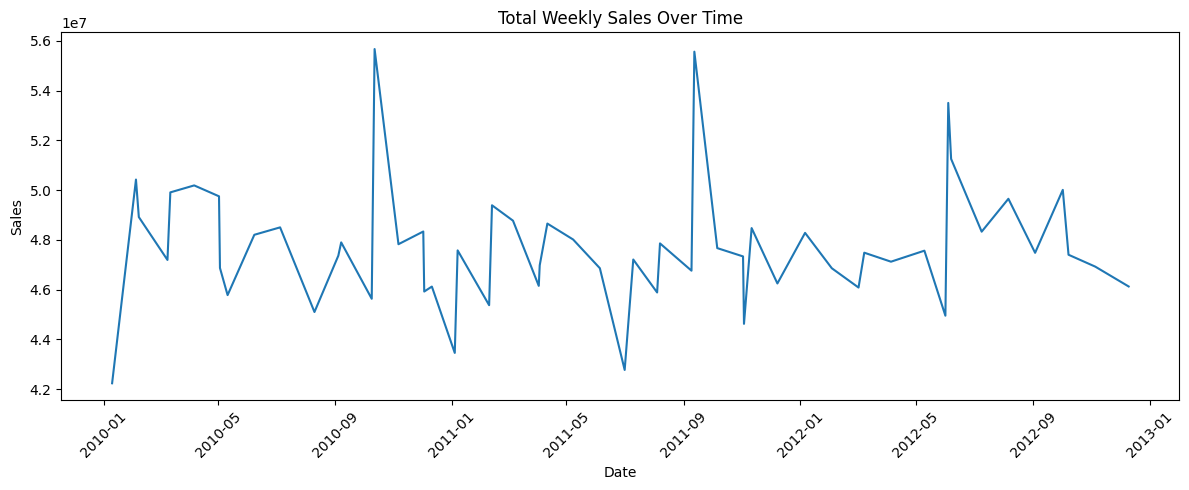

In [2]:
query = """
SELECT date, SUM(weekly_sales) AS total_sales
FROM Sales
GROUP BY date
ORDER BY date;
"""

df = pd.read_sql_query(query, conn)

df["date"] = pd.to_datetime(df["date"])

plt.figure(figsize=(12,5))
plt.plot(df["date"], df["total_sales"])
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

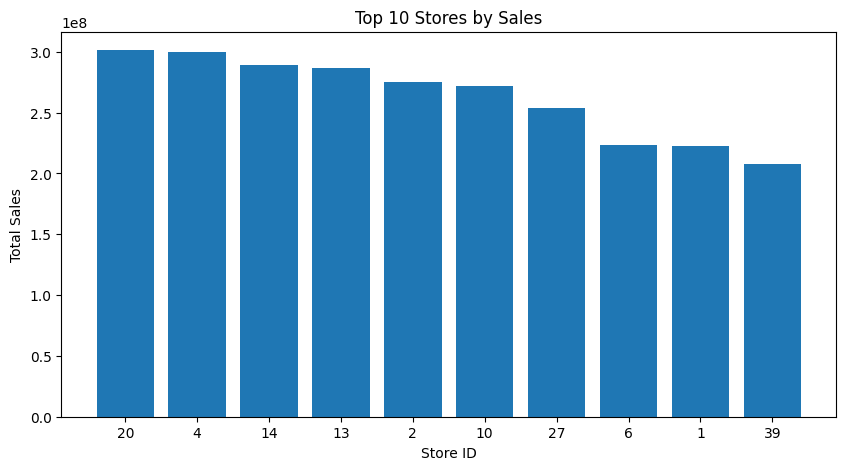

In [3]:
query = """
SELECT store_id, SUM(weekly_sales) AS total_sales
FROM Sales
GROUP BY store_id
ORDER BY total_sales DESC
LIMIT 10;
"""

df = pd.read_sql_query(query, conn)

plt.figure(figsize=(10,5))
plt.bar(df["store_id"].astype(str), df["total_sales"])
plt.title("Top 10 Stores by Sales")
plt.xlabel("Store ID")
plt.ylabel("Total Sales")
plt.show()

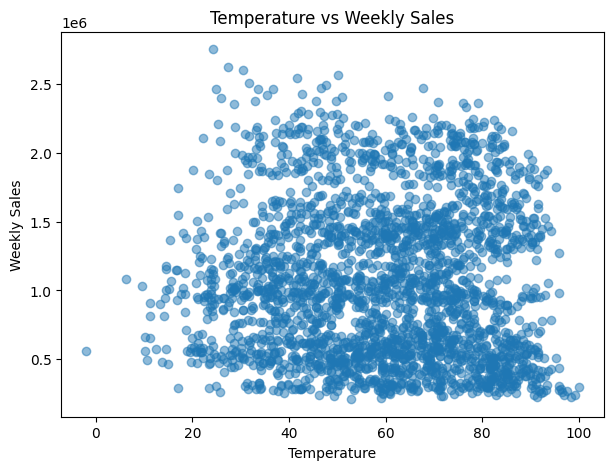

In [4]:
query = """
SELECT 
    s.weekly_sales,
    e.temperature
FROM Sales s
JOIN External_Factors e
ON s.store_id = e.store_id AND s.date = e.date;
"""

df = pd.read_sql_query(query, conn)

plt.figure(figsize=(7,5))
plt.scatter(df["temperature"], df["weekly_sales"], alpha=0.5)
plt.title("Temperature vs Weekly Sales")
plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")
plt.show()

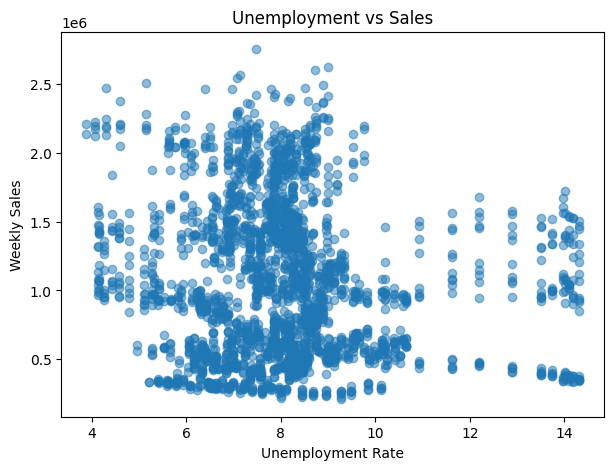

In [5]:
query = """
SELECT 
    s.weekly_sales,
    e.unemployment
FROM Sales s
JOIN External_Factors e
ON s.store_id = e.store_id AND s.date = e.date;
"""

df = pd.read_sql_query(query, conn)

plt.figure(figsize=(7,5))
plt.scatter(df["unemployment"], df["weekly_sales"], alpha=0.5)
plt.title("Unemployment vs Sales")
plt.xlabel("Unemployment Rate")
plt.ylabel("Weekly Sales")
plt.show()

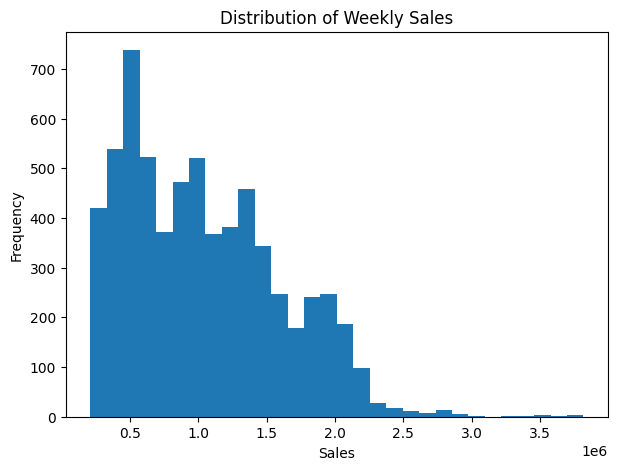

In [6]:
df = pd.read_sql_query("SELECT weekly_sales FROM Sales", conn)

plt.figure(figsize=(7,5))
plt.hist(df["weekly_sales"], bins=30)
plt.title("Distribution of Weekly Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()